<a href="https://colab.research.google.com/github/cgm2179/indoor-walk-test/blob/main/Physics%20Engine/3D%20Map%20Physics/SIM%20V1%203D/phase_b3_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIM V1 3D — Phase B: generate the surrogate dataset

Solves `SceneV3` at many transmitter positions and stores the result as the training
target for Phase C. **CPU runtime is correct here** — `SceneV3` is NumPy, so a GPU
runtime costs quota and buys nothing.

| | |
|---|---|
| **Target** | `pl_norm` (per Tx x band) + `tau_norm` (per Tx) |
| **Inputs** | stored as `(tx, freq)` only — the geometry is fixed, so it is never repeated per sample |
| **Shards** | raw `.npy` volumes + a small `.npz` of metadata, resumable |
| **Runtime** | ~4 s per position; 1,000 positions is roughly 1 h |

Everything about *what the tensors mean* lives in `dataset_3d.py`, which Phase C and the
browser both import. Do not redefine normalization or channel order in this notebook.

## Before you run

**Best:** put the whole git clone on Drive and set
`ROOT = "/content/drive/MyDrive/<repo>/Physics Engine/3D Map Physics/SIM V1 3D"`.

**Minimal:** upload `SIM V1 3D/` (needs `manifest_3d.json`, `material_grid.npy`,
`inside_mask.npy`, `engine_3d.py`, `physics_3d.py`, `dataset_3d.py`) and also copy
`Physics Engine/2D/SIM/physics_v2.py` **into that folder** (Colab fallback path).

A fresh clone already contains those files — `.gitignore` does not strip them.


In [5]:
from pathlib import Path
p = Path("/content/drive/MyDrive/indoor-walk-test-main/Physics Engine/2D/SIM/physics_v2.py")
print(p, "EXISTS" if p.is_file() else "MISSING")

/content/drive/MyDrive/indoor-walk-test-main/Physics Engine/2D/SIM/physics_v2.py EXISTS


In [6]:
#@title Mount Drive, install deps, load the scene
import os, sys, json, time, glob
import numpy as np

ROOT = "/content/drive/MyDrive/indoor-walk-test-main/Physics Engine/3D Map Physics/SIM V1 3D"   #@param {type:"string"}

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# engine_3d solves the eikonal with scikit-fmm; Colab does not ship it.
try:
    import skfmm  # noqa: F401
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-fmm"], check=True)
    import skfmm  # noqa: F401

sys.path.insert(0, ROOT)
import dataset_3d as D
from engine_3d import load_scene

scene, man = load_scene(ROOT)
M       = np.load(f"{ROOT}/material_grid.npy")
inside  = np.load(f"{ROOT}/inside_mask.npy")
norm    = D.load_norm(man)
OUT     = f"{ROOT}/dataset"; os.makedirs(OUT, exist_ok=True)

print("grid          ", M.shape, f"({int(np.prod(M.shape)):,} voxels)")
print("interior      ", f"{int(inside.sum()):,} voxels")
print("scene_sha     ", D.scene_sha(M))
print("bands (MHz)   ", man["freqs_mhz"])
print("norm window   ", f"[{norm.pl_min_db:.0f}, {norm.pl_max_db:.0f}] dB",
      f"| tau ceiling {norm.tau_max_ns:.0f} ns")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
grid           (262, 17, 132) (587,928 voxels)
interior       69,432 voxels
scene_sha      689d48a8799a62f4
bands (MHz)    [619.0, 627.0, 1935.0, 2442.0, 2510.0, 2600.0, 3500.0, 3710.0, 5500.0, 6125.0]
norm window    [40, 170] dB | tau ceiling 400 ns


## Preflight gate — do not skip this

The target is `clip(PL, 40, 170) dB`. Before M2, direct path loss ran to **1,700+ dB**
because `SceneV3` had no saturating obstruction model. That is fixed: `pathloss_maps`
applies `sat_obs` to the direct crossing loss (`physics.use_satobs`, default on), so
interior clip fractions sit well under the 35 % gate.

**Keep running this cell.** It is the regression tripwire — if someone turns `use_satobs`
off or the cap regresses, generation raises above 35 % instead of baking a flat-plateau
dataset. Raising `CLIP_LIMIT` to get past a real failure is still the one thing that
guarantees a worthless model.


In [7]:
#@title Preflight: how much of the target saturates the clip ceiling?
CLIP_LIMIT = 0.35      #@param {type:"number"}  max tolerable clipped fraction
N_PROBE    = 4         #@param {type:"integer"}

rep = D.clip_report(scene, man, inside, norm, n_probe=N_PROBE, seed=0)
print(f"clip ceiling {rep['pl_max_db']:.0f} dB, averaged over {rep['n_probe']} random Tx\n")
print(f"{'band (MHz)':>12} {'clipped':>9} {'median PL':>11}")
for f in sorted(rep["clipped_fraction"]):
    print(f"{f:12.0f} {rep['clipped_fraction'][f]*100:8.1f}% {rep['median_pl_db'][f]:10.1f} dB")

worst = rep["worst_clipped_fraction"]
print(f"\nworst clipped fraction: {worst*100:.1f}%  (limit {CLIP_LIMIT*100:.0f}%)")
if worst > CLIP_LIMIT:
    raise SystemExit(
        f"PREFLIGHT FAILED — {worst*100:.1f}% of interior voxels saturate the {rep['pl_max_db']:.0f} dB "
        "ceiling.\nThe dataset would be mostly a constant. Check SceneV3.use_satobs / sat_obs "
        "(M2 saturating-obstruction) — see PLAN_3D_SIM.md.")
print("preflight OK")


clip ceiling 170 dB, averaged over 4 random Tx

  band (MHz)   clipped   median PL
         619      0.0%      131.6 dB
         627      0.0%      131.8 dB
        1935      0.0%      150.9 dB
        2442      0.0%      154.3 dB
        2510      0.0%      154.7 dB
        2600      0.0%      155.2 dB
        3500      0.1%      159.2 dB
        3710      0.6%      159.9 dB
        5500     13.1%      164.4 dB
        6125     19.2%      165.5 dB

worst clipped fraction: 19.2%  (limit 35%)
preflight OK


## Config

`SMOKE = True` runs 6 positions end-to-end in about a minute — always do that first, because
the failure you want to find (a Drive path, a missing `physics_v2.py`) shows up in the first
sample, not the thousandth.

**Bands are the same for every position on purpose.** Phase C's band-ordering and reciprocity
losses compare two samples that differ in exactly one variable, which needs every position to
carry the same band set.


In [8]:
#@title Dataset config
SMOKE         = True    #@param {type:"boolean"}
N_POSITIONS   = 1000    #@param {type:"integer"}
SHARD_POS     = 25      #@param {type:"integer"}   positions per shard
TRAIN_BANDS   = [619.0, 1935.0, 2442.0, 3500.0, 5500.0, 6125.0]  # spans 600-6200 MHz
TAU_BAND_MHZ  = 3500.0  # eikonal is ~frequency-independent here; one solve per position

if SMOKE:
    N_POSITIONS, SHARD_POS = 16, 8   # enough that all three splits are non-empty

splits_file = f"{OUT}/splits.json"
sp = json.load(open(splits_file))
if sp.get("scene_sha") != D.scene_sha(M):
    raise SystemExit(
        f"splits.json was built for scene {sp.get('scene_sha')}, this scene is {D.scene_sha(M)}.\n"
        "Re-run `python dataset_3d.py` sampling to rebuild it, or the split is meaningless.")

positions = np.array(sp["positions"], np.int16)
N_POSITIONS = min(N_POSITIONS, len(positions))
mb = np.prod(M.shape) * 2 / 1e6
print(f"{len(positions)} positions available (spacing {sp['spacing_voxels']}, "
      f"from {sp['sampled_from']}); using {N_POSITIONS}")
print(f"{N_POSITIONS} x {len(TRAIN_BANDS)} bands = {N_POSITIONS*len(TRAIN_BANDS)} samples")
print(f"projected size: PL {N_POSITIONS*len(TRAIN_BANDS)*mb/1000:.1f} GB "
      f"+ tau {N_POSITIONS*mb/1000:.1f} GB")


1500 positions available (spacing 3.0, from inside_mask); using 16
16 x 6 bands = 96 samples
projected size: PL 0.1 GB + tau 0.0 GB


## Generate shards

Resumable: a shard is written to `.tmp` names and renamed only once all three files are
complete, so a disconnected runtime never leaves a half shard that a later run would trust.
Re-run this cell to pick up where it stopped.


In [9]:
#@title Solve and write shards (re-runnable)
n_shards = int(np.ceil(N_POSITIONS / SHARD_POS))
band_idx = [scene.band_index(f) for f in TRAIN_BANDS]
t_start, done = time.time(), 0

for s in range(n_shards):
    if D.shard_complete(OUT, s):
        print(f"shard {s:03d}: complete, skipping"); continue
    p0, p1 = s * SHARD_POS, min((s + 1) * SHARD_POS, N_POSITIONS)
    pl_rows, tau_rows = [], []
    m_tx, m_f, m_ff, m_pos, m_taurow = [], [], [], [], []

    for pi in range(p0, p1):
        tx = tuple(float(v) for v in positions[pi])
        PL = scene.pathloss_maps(tx)                     # one geometric pass, all bands
        T  = scene.arrival_time(tx, TAU_BAND_MHZ)
        tau_rows.append(norm.tau_to_norm(T))
        for f, bi in zip(TRAIN_BANDS, band_idx):
            pl_rows.append(norm.pl_to_norm(PL[bi]))
            m_tx.append(positions[pi]); m_f.append(f)
            m_ff.append(norm.freq_feature(f)); m_pos.append(pi)
            m_taurow.append(len(tau_rows) - 1)
        done += 1

    D.write_shard(OUT, s, np.stack(pl_rows), np.stack(tau_rows), dict(
        tx=np.array(m_tx, np.int16), freq_mhz=np.array(m_f, np.float32),
        freq_feat=np.array(m_ff, np.float32), pos_id=np.array(m_pos, np.int32),
        tau_row=np.array(m_taurow, np.int32), scene_sha=D.scene_sha(M),
        bands_mhz=np.array(TRAIN_BANDS, np.float32)))

    rate = (time.time() - t_start) / max(done, 1)
    left = (N_POSITIONS - p1) * rate
    print(f"shard {s+1:3d}/{n_shards}  positions {p0}-{p1-1}  "
          f"{rate:.1f} s/pos  ETA {left/60:.0f} min")

print(f"\ndone: {len(D.list_shards(OUT))} shards in {(time.time()-t_start)/60:.1f} min")


shard   1/2  positions 0-7  8.8 s/pos  ETA 1 min
shard   2/2  positions 8-15  8.9 s/pos  ETA 0 min

done: 2 shards in 2.4 min


## Sanity check

Reads a shard back **through the memmap path Phase C will use**, denormalizes, and plots a
horizontal slice at the Tx height. Loss should be low at the star and rise with distance and
through walls. The printed round-trip error is the fp16 quantization floor, so it should sit
near 0.01 dB, not near 1 dB.


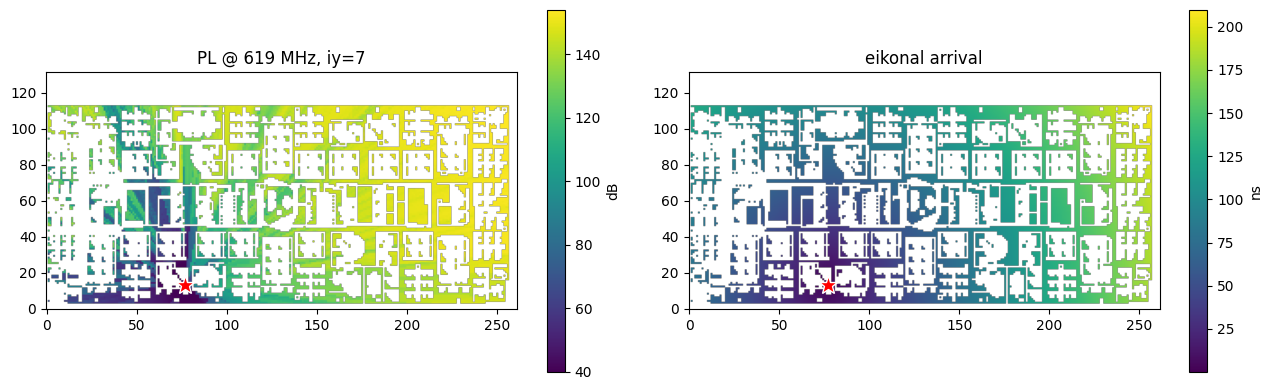

Tx [77, 7, 13]  interior PL 40.0 - 154.0 dB
tau max 211 ns
fp16 round-trip error vs a fresh solve: 0.0317 dB

Dataset ready. Next: phase_c3_train_colab.ipynb


In [10]:
#@title Read one sample back and plot it
import matplotlib.pyplot as plt

pl, tau, meta = D.open_shard(OUT, 0)
i  = 0
tx = meta["tx"][i]; f = float(meta["freq_mhz"][i])
vol = norm.norm_to_pl(np.asarray(pl[i], np.float32))
tv  = norm.norm_to_tau_ns(np.asarray(tau[int(meta["tau_row"][i])], np.float32))
iy  = int(tx[1])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, img, title, cb in (
        (ax[0], np.where(inside, vol, np.nan)[:, iy, :].T, f"PL @ {f:.0f} MHz, iy={iy}", "dB"),
        (ax[1], np.where(inside, tv, np.nan)[:, iy, :].T, "eikonal arrival", "ns")):
    im = a.imshow(img, origin="lower", cmap="viridis")
    a.plot(tx[0], tx[2], "r*", ms=14, mec="white"); a.set_title(title)
    fig.colorbar(im, ax=a, label=cb)
plt.tight_layout(); plt.show()

ref = scene.pathloss_maps(tuple(float(v) for v in tx))[scene.band_index(f)]
err = np.abs(np.clip(ref, norm.pl_min_db, norm.pl_max_db) - vol)[inside].max()
print(f"Tx {tx.tolist()}  interior PL {vol[inside].min():.1f} - {vol[inside].max():.1f} dB")
print(f"tau max {tv[inside].max():.0f} ns")
print(f"fp16 round-trip error vs a fresh solve: {err:.4f} dB")
assert err < 0.2, "shard does not reproduce the engine - check norm/band indexing"
print("\nDataset ready. Next: phase_c3_train_colab.ipynb")
